In [1]:
import numpy as np
import wfdb
import pywt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np

In [2]:
# Load the datasets
X_train = np.load('TEST1/X_train.npy')
y_train = np.load('TEST1/y_train.npy')
X_test = np.load('TEST1/X_test.npy')
y_test = np.load('TEST1/y_test.npy')

C:\Users\user\AppData\Local\Temp\ipykernel_9268\4244235824.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


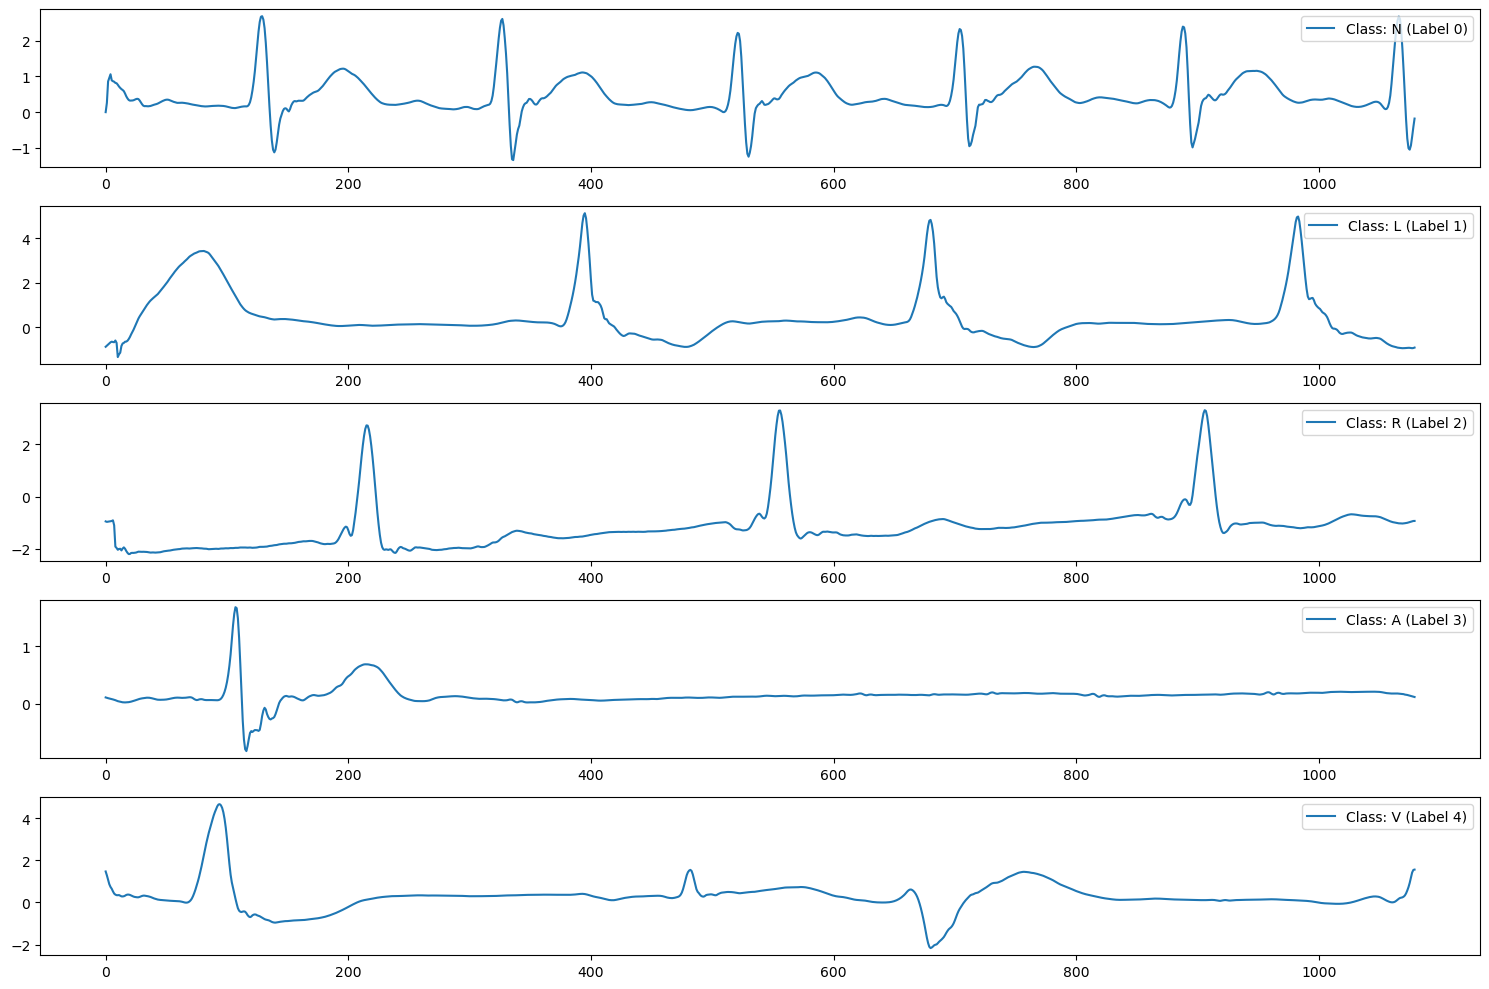

In [3]:
#Plot a signal from each class

import matplotlib.pyplot as plt
import numpy as np

label_mapping = {'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4}


def plot_one_signal_per_class(X, y, label_mapping):
    # Create a reverse mapping from label number to label name
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}
    
    # Find indices of one example per class
    unique_labels = np.unique(y)
    example_indices = []
    for label in unique_labels:
        example_index = np.where(y == label)[0][0]  # Get the index of the first occurrence of each label
        example_indices.append(example_index)
    
    # Plotting
    plt.figure(figsize=(15, 10))
    for i, index in enumerate(example_indices):
        plt.subplot(len(unique_labels), 1, i + 1)
        plt.plot(X[index], label=f"Class: {reverse_label_mapping[y[index]]} (Label {y[index]})")
        plt.legend(loc="upper right")
        plt.tight_layout()
    
    plt.show()


plot_one_signal_per_class(X_train, y_train, label_mapping)

In [4]:
# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(8, 5, activation='relu', padding='same', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(16, 5, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(32, 5, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=False)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Convert labels to numpy arrays if they aren't already
y_train = np.array(y_train)
y_test = np.array(y_test)


if len(X_train.shape) == 2:
    X_train = np.expand_dims(X_train, axis=-1)  # Add a channel dimension, if necessary
if len(X_test.shape) == 2:
    X_test = np.expand_dims(X_test, axis=-1)  # Add a channel dimension, if necessary

# Print the shapes of the dataset
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (20193, 1080, 1)
y_train shape: (20193,)
X_test shape: (8655, 1080, 1)
y_test shape: (8655,)


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint
# Train the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
checkpoint_path = 'MODElS/CNNBILSTM.keras'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=1, callbacks=[early_stopping , checkpoint])

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy}")

Epoch 1/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7760 - loss: 0.8566 - val_accuracy: 0.7991 - val_loss: 0.5754
Epoch 2/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8137 - loss: 0.5441 - val_accuracy: 0.8468 - val_loss: 0.4116
Epoch 3/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8884 - loss: 0.3287 - val_accuracy: 0.9042 - val_loss: 0.2602
Epoch 4/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9373 - loss: 0.1961 - val_accuracy: 0.9507 - val_loss: 0.1468
Epoch 5/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9571 - loss: 0.1339 - val_accuracy: 0.9650 - val_loss: 0.1136
Epoch 6/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9649 - loss: 0.1085 - val_accuracy: 0.9680 - val_loss: 0.1022
Epoch 7/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9540 - loss: 0.1405 - val_accuracy: 0.9680 - val_loss: 0.0873
Epoch 8/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9718 - loss: 0

In [7]:
from tensorflow.keras.models import load_model
loaded_model = load_model(checkpoint_path)

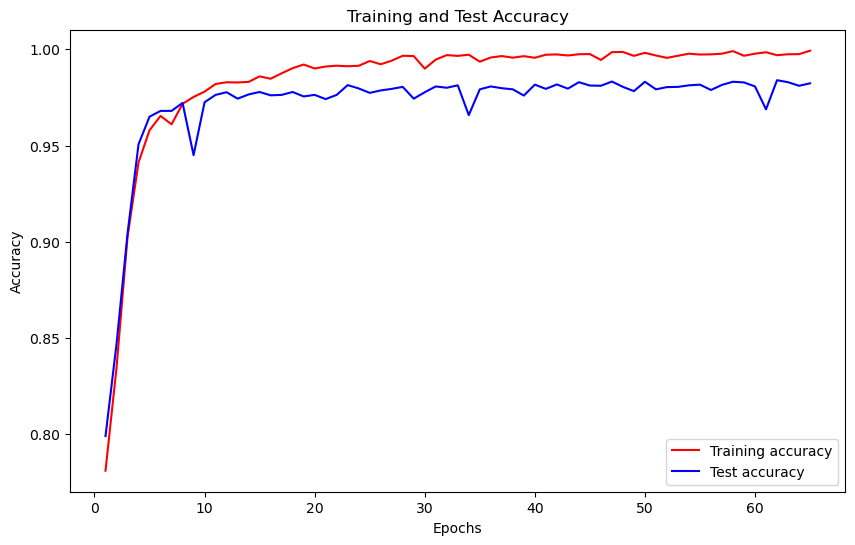

In [8]:
# Plot training and test accuracies over epochs
import matplotlib.pyplot as plt


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)  # Number of epochs


plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'r', label='Training accuracy')  # 'bo' gives blue color and dot markers
plt.plot(epochs, val_acc, 'b', label='Test accuracy')   # 'b' gives solid blue line
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate predictions
y_pred = loaded_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [10]:
# Print classification report
class_report = classification_report(y_test, y_pred_classes, target_names=['N', 'L', 'R', 'A', 'V'])
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           N       0.99      0.99      0.99      6759
           L       0.99      0.99      0.99       667
           R       0.99      0.98      0.98       617
           A       0.97      0.81      0.88       199
           V       0.81      0.91      0.85       413

    accuracy                           0.98      8655
   macro avg       0.95      0.93      0.94      8655
weighted avg       0.98      0.98      0.98      8655



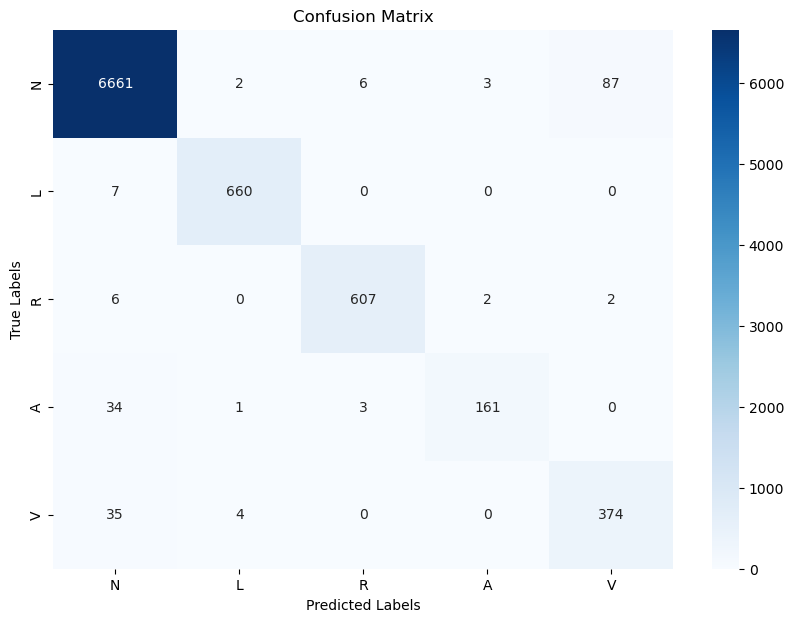

In [11]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['N', 'L', 'R', 'A', 'V'], yticklabels=['N', 'L', 'R', 'A', 'V'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


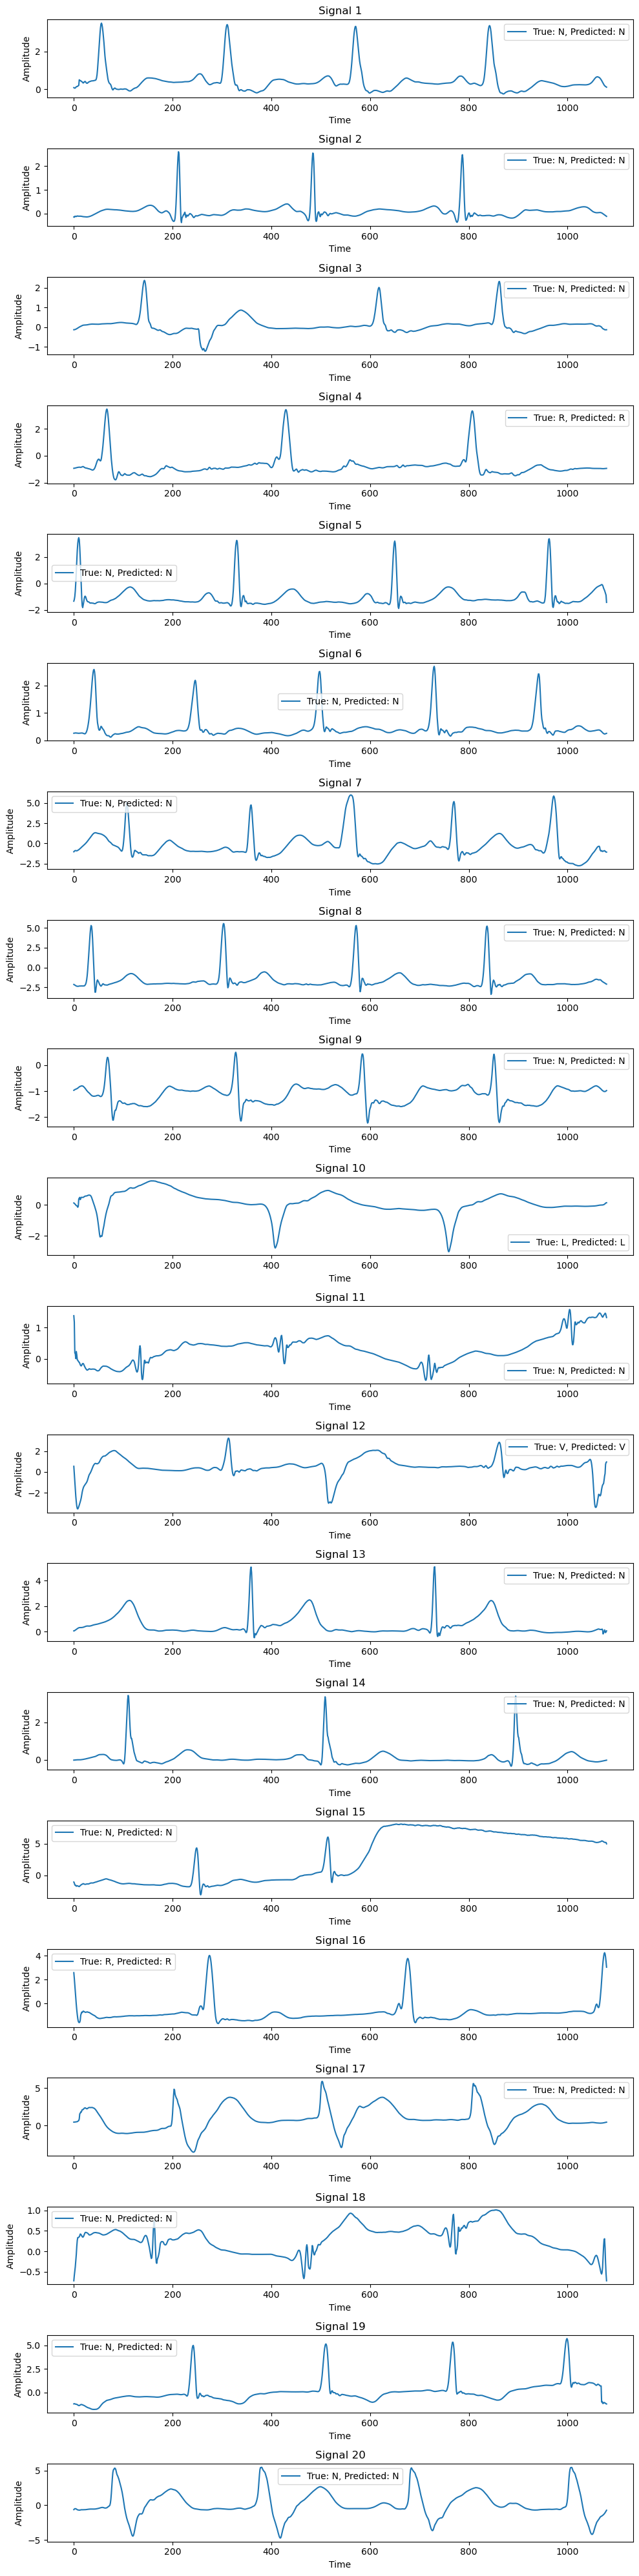

Correct Predictions: 8463
Incorrect Predictions: 192


In [12]:
# Plot sample signals with true and predicted labels, and display prediction accuracy

label_mapping = {'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4}
def plot_and_predict(X_test, y_test, model, label_mapping, num_samples=10):
    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))
    
    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct
    
    # Reverse label mapping for easy plotting
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}
    
    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i].flatten()  # Flatten the 2D signal to 1D for plotting
        true_label = reverse_label_mapping.get(y_test[i], 'Unknown')
        predicted_label = reverse_label_mapping.get(predicted_labels[i], 'Unknown')
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")


plot_and_predict(X_test, y_test, loaded_model, label_mapping, num_samples=20)